## ***TALLER PRÁCTICO – MACHINE LEARNING***

### ***Clasificación vs Regresión (Elección del modelo)***

Objetivo del taller
Aplicar un flujo básico de Machine Learning para resolver un problema real, identificando correctamente si se trata de regresión o clasificación, construyendo un modelo predictivo y evaluando su desempeño.

*By Gabriel  Buitrago Herreño*

#### ***Definicion de DATASET***

**Dataset seleccionado:**

**Dataset 1:** Predicción de precio de un carro
       • https://www.kaggle.com/datasets/hellbuoy/car-price-prediction
    
**Objetivo del negocio:** estimar el precio de un vehículo basado en sus características. 

### Parte 1 – Comprensión del problema

    
**1. Identifica la variable objetivo (target)**  
La Variable objetivo es el campo Loan_Status, el cual confirma si la solicitud del prestamo fue aprobado o rechazado.

**2. Responde:**  
*¿Es un problema de clasificación o regresión?*  
Es un problema de clasificacion.  
*¿Por qué?*   
Porque el objetivo es predecir una categoría (Aprobado o Rechazado) y no un valor numérico continuo. El modelo debe clasificar cada solicitud de préstamo en una de estas dos clases.

**3. Describe brevemente el contexto del problema**  
El objetivo es desarrollar un modelo de Machine Learning que permita predecir si un solicitante sera aprobado o no para un prestamo, utilizando información que se encuentra en el dataset


### Parte 2 – Exploración de datos (EDA básica)

*Revisar valores nulos  
*Identificar variables numéricas y categóricas  
*Detectar la variable objetivo  
*Mostrar al menos 2 gráficos (ej: distribución, conteos o correlación)

In [58]:

# Manipulacion
import pandas as pd
import numpy as np

#Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

# Division de datos para entrenamiento (Aplica usualmente para todos los modelos Logistic Regression,  Decision Tree, Random Forest, SVM , KNN) 
from sklearn.model_selection import train_test_split

# Escala las variables numericas para que tengan un aproximacion de media = 0 desviacion estandar = 1 haciendo las escalas comparables.
# Modelos que usualmente lo usan Logistic Regression, KNN, SVM,Redes neuronales.
from sklearn.preprocessing import StandardScaler

# Busca automáticamente los mejores hiperparámetros para un modelo. (Se usa en todos los modelos para probar y optener la mejor combinacion posible de hiperparametros)
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression # Modelo a utilizar
from sklearn.tree import DecisionTreeClassifier # Modelo a utilizar

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

In [59]:
df1 = pd.read_csv("Loan Prediction Problem Dataset.csv") ## Original Dataset
df = df1.copy() ## Copy creation 

In [60]:
## Revision de Valores Nulos
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [61]:
## Identificacion de variables numericas y categoricas
print("\nInformación del dataset:")
df = df.drop(columns = ("Loan_ID")) ## El loan_ID no va a ser requerido en la evaluacion es mejor eliminarlo desde el inicio
df.info()


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [62]:
## Detalles del dataset e identificacion de la variable objetivo
print("Primera vista del dataset:")
display(df.head())
print("\nDistribución de la variable objetivo:")
print(df["Loan_Status"].value_counts())

Primera vista del dataset:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



Distribución de la variable objetivo:
Loan_Status
Y    422
N    192
Name: count, dtype: int64


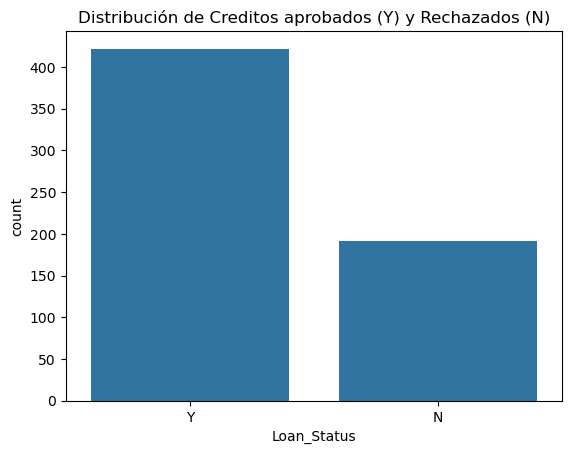

In [63]:
## visualización de las categorias en el campo target
sns.countplot(x="Loan_Status", data=df)
plt.title("Distribución de Creditos aprobados (Y) y Rechazados (N)")
plt.show()

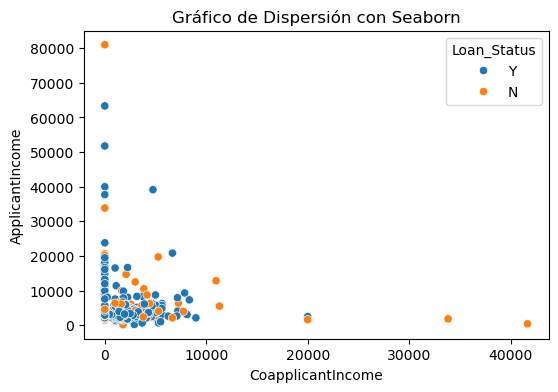

In [64]:
## visualizacion de correlacion
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="CoapplicantIncome", y="ApplicantIncome", hue="Loan_Status")
plt.title("Gráfico de Dispersión con Seaborn")
plt.show()

## Al parecer no existe una correlacion directa entre si el aplicante y coaplicante tienen ingresos bastante altos, esto garantiza la aprobacion del credito.
# Como se observa es bueno tener ingresos en ambos casos, pero aun asi algunos credito fueron rechazados con applicante y coaplicantes con los mayores incomes

### Parte 3 – Preparación de datos
*Manejo de valores faltantes*  
*Codificación de variables categóricas*  
*Separación en:*  
***X (variables predictoras)***  
***y (variable objetivo)***  
*División entrenamiento / prueba (80/20 o 70/30)* 

In [65]:
## Identificacion de valores faltantes 
df.isnull().sum() 
# df.info()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [66]:
## Manejo valores faltantes 

## Ajuste atraves de la moda 
categoricas = ["Gender", "Married", "Dependents",
               "Self_Employed", "Loan_Amount_Term",
               "Credit_History"]

for col in categoricas:
    df[col] = df[col].fillna(df[col].mode()[0])

## Ajuste atraves del promedio
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

## Validacion
df.isnull().sum() 


Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [67]:
## Codificacion de variables Categoricas
df = pd.get_dummies(df, drop_first=True)
# df.info()


In [68]:
## Separacion de variables X (variables predictoras) y (variable objetivo)
X = df.drop("Loan_Status_Y", axis=1)
y = df["Loan_Status_Y"]

# y.info()
# x.info()


In [69]:
## División entrenamiento / prueba (80/20)
# from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Parte 4 – Modelado
*Entrenar al menos 2 modelos*

In [70]:
# Modelo de regresion Logistica
# Escalamiento de variables numericas
# from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [71]:
#Creacion del modelo, sin optimizacion de ajustes de hiperparametros
# from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(
    random_state=42,
    max_iter=500,
    # multi_class="multinomial", # Profe no entendi por que me registraba error al hacer uso de este parametro asi que lo comente.
    solver="lbfgs"
)

#Entrenamiento
modelo_lr.fit(X_train_scaled, y_train)

#Prediccion sobre el conjunto de prueba
y_pred = modelo_lr.predict(X_test_scaled)

#Evaluacion del modelp
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8617886178861789
F1 Score: 0.9081081081081082
              precision    recall  f1-score   support

       False       0.96      0.58      0.72        38
        True       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



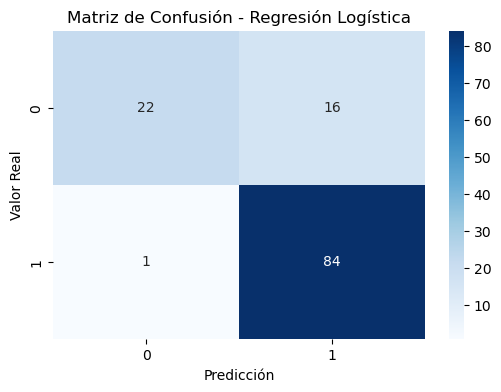

In [72]:
# Matriz de confusion
# from sklearn.metrics import confusion_matrix
cm_lr = confusion_matrix(y_test, y_pred)

#Visualizacion matriz de confusion
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

Mejores hiperparámetros:
{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}

Mejor Accuracy:
0.7983714698000413

Accuracy: 0.8617886178861789
F1 Score: 0.9081081081081082
              precision    recall  f1-score   support

       False       0.96      0.58      0.72        38
        True       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



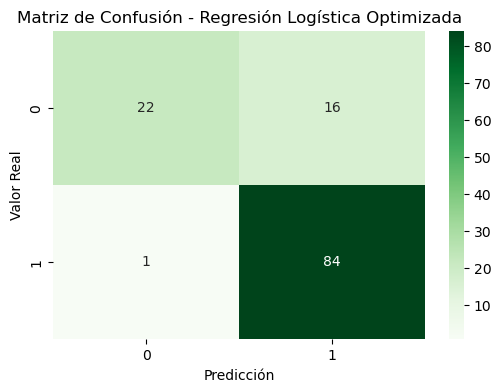

In [73]:
## Regresion Logistica con optimizacion de ajuste de hiperparametros automaticos

## Creacion del modelo
modelo_lr2 = LogisticRegression(
    random_state=42,
    max_iter=500
)

# Definición de los hiperparámetros a evaluar
parametros = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "liblinear"],
    "penalty": ["l2"]
}

# Configuración del GridSearchCV
grid = GridSearchCV(
    estimator=modelo_lr2,
    param_grid=parametros,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Entrenamiento y búsqueda del mejor modelo
grid.fit(X_train_scaled, y_train)

# Mejor modelo encontrado
modelo_lr2_best = grid.best_estimator_

print("Mejores hiperparámetros:")
print(grid.best_params_)

print("\nMejor Accuracy:")
print(grid.best_score_)

# Predicción
y_pred_lr2 = modelo_lr2_best.predict(X_test_scaled)

# Evaluación del modelo
print("\nAccuracy:", accuracy_score(y_test, y_pred_lr2))
print("F1 Score:", f1_score(y_test, y_pred_lr2))
print(classification_report(y_test, y_pred_lr2))

# Matriz de confusión
cm_lr2 = confusion_matrix(y_test, y_pred_lr2)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr2,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Matriz de Confusión - Regresión Logística Optimizada")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

In [74]:
## Modelo arbol de decision
## Creacion del modelo, sin optimizacion de ajustes de hiperparametros

modelo_dt = DecisionTreeClassifier(
    random_state=42
)

## Entrenamiento
modelo_dt.fit(X_train, y_train)

## Prediccion sobre el conjunto de prueba
y_pred = modelo_dt.predict(X_test)

## Evaluacion del modelo
print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))
print("\nF1 Score:")
print(f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy:
0.7154471544715447

F1 Score:
0.7878787878787878
              precision    recall  f1-score   support

       False       0.53      0.61      0.57        38
        True       0.81      0.76      0.79        85

    accuracy                           0.72       123
   macro avg       0.67      0.68      0.68       123
weighted avg       0.73      0.72      0.72       123



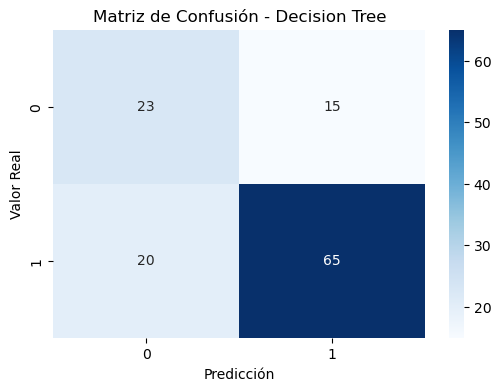

In [75]:
## Matriz de confusion
## from sklearn.metrics import confusion_matrix
cm_dt = confusion_matrix(y_test, y_pred)

## Visualizacion matriz de confusion
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusión - Decision Tree")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

Mejores hiperparámetros:
{'criterion': 'entropy', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}

Mejor Accuracy:
0.7922490208204495

Accuracy: 0.8536585365853658
F1 Score: 0.9032258064516129
              precision    recall  f1-score   support

       False       0.95      0.55      0.70        38
        True       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



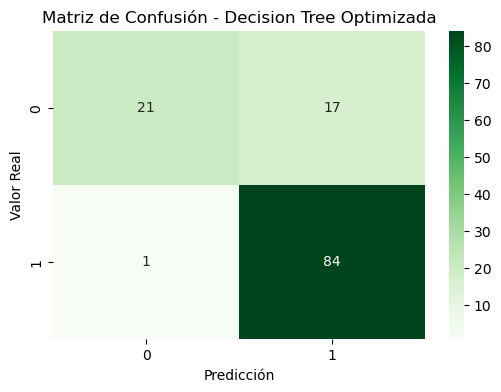

In [76]:
## Decision Tree con optimizacion de ajuste de hiperparametros automaticos haciendo uso de GridSearchCV
## proceso completo 
## Creación del modelo
modelo_dt2 = DecisionTreeClassifier(
    random_state=42
)

## Definición de los hiperparámetros a evaluar
parametros = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 4, 6, 8, 10], ## Profundidad maxima del arbol
    "min_samples_split": [2, 5, 10], ## la cantidad minima de datos o registros para dividir a un nodo
    "min_samples_leaf": [1, 2, 4] ## la cantidad minima de registros por hoja
}

## Ajuste y configuración del GridSearchCV
grid = GridSearchCV(
    estimator=modelo_dt2, ## Aca determina el arbol como decide sus divisiones
    param_grid=parametros, 
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

## Entrenamiento y búsqueda del mejor modelo
grid.fit(X_train, y_train)

## Mejor modelo encontrado
modelo_dt2_best = grid.best_estimator_

print("Mejores hiperparámetros:")
print(grid.best_params_)

print("\nMejor Accuracy:")
print(grid.best_score_)

# Predicción sobre el conjunto de prueba
y_pred_dt = modelo_dt2_best.predict(X_test)

# Evaluación del modelo
print("\nAccuracy:", accuracy_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

# Matriz de confusión
cm_dt2 = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt2,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Matriz de Confusión - Decision Tree Optimizada")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

### Parte 6 – Interpretación
**Responder:**   

**¿Qué tan bueno es el modelo?**

Contemplando todos los modelos creados, el mejor es el de regresion logistica sin ajuste de hiperparametros ya que genera un accuracy del 86%, sin embargo me causa un poco de intriga dado que en el modelo de arbol se ve una mejora al hacer uso del ajuste de hiperparametros pasando de 71% a 79% con ajuste de hiperparametros.

**¿Qué variable parece influir más en la predicción?**  

En los parametros de division de entrenamiento evidencie que el uso del stratify=y procura que la proporción de clases (por ejemplo, préstamos aprobados y rechazados) sea similar tanto en entrenamiento como en prueba asi que el no uso de esta afecta bastante el desarrollo en el modelo en general. Esto hace que la evaluación del modelo sea más representativa, especialmente si una clase es más frecuente que la otra. 

Adicional, el escalamiento de variables para la regresion ayudaron bastante a que hubiese mayor acierto entendiendo su funcion para evitar sesgos. 

**¿Qué mejorarías si tuvieras más tiempo?**  

Con mayor tiempo me gustaria validar algun otro modelo para ver si podemos elevar la cantidad de acierto con respecto a los modelos creados con y sin hiperparametros, adicional indagaria un poco mas de el por que tal vez el modelo de regresion logistica funciono mejor sin ajuste u optimizacion de hiperparametros.